# Patient-level dosage scoring test

In [71]:
import numpy as np
import pandas as pd

from __future__ import annotations

from collections.abc import Sequence
from dataclasses import replace
from time import perf_counter
from typing import Any
from tqdm.auto import tqdm
from importlib.resources import files
import os
from joblib import Parallel, delayed


from cmdstanpy import CmdStanModel
import bdgdm
from bdgdm import load_example_data, fit_one_gene_bdgdm, BDGDMConfig
from bdgdm.patient_scores import extract_dosage_draws_from_fits, PatientScoreConfig, compute_patient_scores, save_patient_score_result

In [3]:
# Load example CRC data

#gene_df = load_example_data()
#gene_df.head()

In [3]:
DATA_PATH = "/Users/katsiarynadavydzenka/Documents/PhD_AI/bdgdm_stan/CRC/data/bdgdm_test/"
gene_df = pd.read_csv(os.path.join(DATA_PATH, "crc_joint_long_cohort.csv"))

In [5]:
gene_df.head()

,gene,sampleID,expr,copies,subtype,purity,ploidy,sf
0,A1BG,CRC.SW.U0001.T,12,3.0,MSS,0.41,3.8,1.293201
1,A1BG,CRC.SW.U0002.T,3,2.0,MSS,0.37,3.3,1.024008
2,A1BG,CRC.SW.U0004.T,14,3.0,MSS,0.58,3.2,1.169870
3,A1BG,CRC.SW.U0030.T,4,2.0,MSS,0.59,2.2,1.290047
4,A1BG,CRC.SW.U0066.T,4,2.0,MSS,0.41,1.9,0.971163


In [7]:
# Select MSS

mss_df = (gene_df.loc[gene_df["subtype"].astype(str).eq("MSS")]
    .copy()
    .reset_index(drop=True))

print("MSS patients:", mss_df["sampleID"].nunique())
print("MSS genes:", mss_df["gene"].nunique())
print("MSS rows:", len(mss_df))

MSS patients: 778
MSS genes: 16199
MSS rows: 12602822


In [9]:
# Calculate patient-level CNA statistics
# For patient selection, calculate two quantities:
# fga_ploidy: alterations relative to the patient’s rounded ploidy;
# altered_fraction_cn2: alterations relative to CN2.

ET = 0.15
CN2_ALTERED_DISTANCE = 1.0 - ET

mss_df["ploidy_baseline"] = np.rint(mss_df["ploidy"])

# Used only to select patients with different global CNA burdens.
mss_df["altered_ploidy"] = (np.abs(mss_df["copies"] - mss_df["ploidy_baseline"]) > 0.5)

# Consistent with the BDGDM CN2-relative definition.
mss_df["altered_cn2"] = (np.abs(mss_df["copies"] - 2.0) > CN2_ALTERED_DISTANCE)

patient_stats = (
    mss_df
    .groupby("sampleID", as_index=False)
    .agg(
        subtype=("subtype", "first"),
        purity=("purity", "first"),
        ploidy=("ploidy", "first"),
        n_genes=("gene", "nunique"),
        agf_ploidy=("altered_ploidy", "mean"),
        altered_fraction_cn2=("altered_cn2", "mean")
    )
)

patient_stats.head()

,sampleID,subtype,purity,ploidy,n_genes,agf_ploidy,altered_fraction_cn2
0,CRC.SW.U0001.T,MSS,0.41,3.8,16199,0.979752,0.095438
1,CRC.SW.U0002.T,MSS,0.37,3.3,16199,0.881289,0.127354
2,CRC.SW.U0004.T,MSS,0.58,3.2,16199,0.958516,0.207544
3,CRC.SW.U0030.T,MSS,0.59,2.2,16199,0.033829,0.033829
4,CRC.SW.U0066.T,MSS,0.41,1.9,16199,0.000000,0.000000


This **agf_ploidy** is gene-based rather than segment-length-based, so it is suitable for selecting a diverse test subset, 
not as the final clinical FGA measure.

In [15]:
# Select MSS patients across CNA-burden

def select_patients_by_burden(
    patient_stats: pd.DataFrame,
    *,
    n_patients: int = 50,
    sample_col: str = "sampleID",
    burden_col: str = "agf_ploidy",
    random_state: int = 123,
) -> tuple[list[str], pd.DataFrame]:
    """
    Select patients approximately equally from low, medium,
    and high CNA-burden tertiles.
    """
    stats = patient_stats.copy()

    if stats.empty:
        raise ValueError("patient_stats is empty.")

    if stats[sample_col].duplicated().any():
        raise ValueError("patient_stats must contain one row per patient.")

    target = min(int(n_patients), len(stats))

    if target < 3:
        raise ValueError("At least three patients are required.")

    # Ranking avoids qcut failure when many patients have
    # identical burden values.
    ranked_burden = stats[burden_col].rank(method="first")

    stats["burden_group"] = pd.qcut(ranked_burden, q=3, labels=["low", "medium", "high"])

    groups = ["low", "medium", "high"]

    base_n = target // len(groups)
    remainder = target % len(groups)

    selected_parts = []

    for group_index, group in enumerate(groups):
        group_df = stats.loc[stats["burden_group"].eq(group)]

        requested = (base_n + int(group_index < remainder))

        selected_parts.append(
            group_df.sample(
                n=min(requested, len(group_df)),
                random_state=(random_state + group_index))
        )

    selected = pd.concat(selected_parts, ignore_index=True)

    # Fill any remaining places when one tertile is small.
    missing_n = target - len(selected)

    if missing_n > 0:
        remaining = stats.loc[~stats[sample_col].isin(selected[sample_col])]

        selected = pd.concat([selected,
                              remaining.sample(n=min(missing_n, len(remaining)),
                                               random_state=random_state),
                             ],
                             ignore_index=True
                            )

    selected = (selected.sort_values(["burden_group", burden_col])
        .reset_index(drop=True)
    )

    return (
        selected[sample_col].tolist(),
        selected,
    )

In [17]:
selected_patients, selected_patient_stats = (
    select_patients_by_burden(
        patient_stats,
        n_patients=100,
        random_state=123,
    )
)

#selected_patient_stats[["sampleID", "purity", "ploidy", "fga_ploidy", "altered_fraction_cn2", "burden_group"]].head()

selected_patient_stats["burden_group"].value_counts(sort=False)

burden_group
low       34
medium    33
high      33
Name: count, dtype: int64

In [19]:
# Restrict the data to selected patients

selected_patient_df = (mss_df.loc[mss_df["sampleID"].isin(selected_patients)].copy())
print(selected_patient_df["sampleID"].nunique())

100


In [21]:
# Calculate gene-level CN support

selected_patient_df["gain_cn2"] = (selected_patient_df["copies"] > 2.0 + CN2_ALTERED_DISTANCE)

selected_patient_df["loss_cn2"] = (selected_patient_df["copies"] < 2.0 - CN2_ALTERED_DISTANCE)

gene_stats = (
    selected_patient_df
    .groupby("gene", as_index=False)
    .agg(
        n_patients=("sampleID", "nunique"),
        n_unique_cn=("copies", "nunique"),
        n_altered=("altered_cn2", "sum"),
        n_gain=("gain_cn2", "sum"),
        n_loss=("loss_cn2", "sum"),
        cn_mean=("copies", "mean"),
        cn_sd=("copies", "std"),
        cn_min=("copies", "min"),
        cn_max=("copies", "max"))
)

gene_stats["patient_coverage"] = (gene_stats["n_patients"] / len(selected_patients))

In [23]:
# Select genes with different CNA patterns

def select_variable_genes(
    gene_stats: pd.DataFrame,
    *,
    n_genes: int = 20,
    min_altered: int = 5,
    min_unique_cn: int = 3,
    min_patient_coverage: float = 0.95,
    n_bidirectional: int = 5,
    n_gain_dominant: int = 10,
    n_loss_dominant: int = 5,
    random_state: int = 123,
) -> tuple[list[str], pd.DataFrame]:
    """
    Select a mixture of bidirectional, gain-dominant,
    loss-dominant, and other CN-variable genes.
    """
    eligible = gene_stats.loc[(gene_stats["patient_coverage"] >= min_patient_coverage)
    & (gene_stats["n_altered"] >= min_altered) 
    & (gene_stats["n_unique_cn"] >= min_unique_cn)].copy()

    if eligible.empty:
        raise ValueError(
            "No genes satisfy the current CN-support criteria."
        )

    selected_genes: list[str] = []
    selection_labels: dict[str, str] = {}

    def add_genes(
        pool: pd.DataFrame,
        n: int,
        label: str,
    ) -> None:
        available = pool.loc[~pool["gene"].isin(selected_genes)]

        chosen = (available
                  .head(n)["gene"]
                  .astype(str)
                  .tolist())

        selected_genes.extend(chosen)

        for gene in chosen:
            selection_labels[gene] = label

    # Genes with both gains and losses.
    bidirectional_pool = (eligible.loc[(eligible["n_gain"] >= 3) & (eligible["n_loss"] >= 3)]
        .sort_values(["n_altered", "cn_sd"],
                     ascending=False)
                         )

    add_genes(bidirectional_pool, n_bidirectional, "bidirectional")

    # Predominantly gained genes.
    gain_pool = (
        eligible.loc[
            (eligible["n_gain"] >= min_altered)
            & (eligible["n_gain"] > eligible["n_loss"])
        ]
        .sort_values(["n_gain", "cn_sd"], ascending=False)
    )

    add_genes(gain_pool, n_gain_dominant, "gain_dominant")

    # Predominantly lost genes.
    loss_pool = (eligible.loc[(eligible["n_loss"] >= min_altered) 
                 & (eligible["n_loss"] > eligible["n_gain"])]
                 .sort_values(["n_loss", "cn_sd"], ascending=False)
                )

    add_genes(loss_pool, n_loss_dominant, "loss_dominant")

    # Fill remaining places using other variable genes.
    remaining_n = min(n_genes, len(eligible)) - len(selected_genes)

    if remaining_n > 0:
        remaining_pool = eligible.loc[~eligible["gene"].isin(selected_genes)].copy()
        remaining_pool = remaining_pool.sort_values(["n_altered", "cn_sd"], ascending=False)

        # Take from a broad high-variation pool rather than
        # only the very top genes.
        candidate_pool = remaining_pool.head(
            max(remaining_n * 3, remaining_n)
        )

        fill_genes = (candidate_pool.sample(n=min(remaining_n, len(candidate_pool)),
                                            random_state=random_state)["gene"]
                      .astype(str)
                      .tolist()
                     )

        selected_genes.extend(fill_genes)

        for gene in fill_genes:
            selection_labels[gene] = ("other_variable")

    selected_gene_stats = (eligible.loc[eligible["gene"].isin(selected_genes)].copy())

    selected_gene_stats["selection_group"] = selected_gene_stats["gene"].map(selection_labels)

    order = {
        gene: index
        for index, gene
        in enumerate(selected_genes)
    }

    selected_gene_stats["_selection_order"] = selected_gene_stats["gene"].map(order)

    selected_gene_stats = (
        selected_gene_stats
        .sort_values("_selection_order")
        .drop(columns="_selection_order")
        .reset_index(drop=True)
    )

    return (selected_genes, selected_gene_stats)

In [25]:
selected_genes, selected_gene_stats = (
    select_variable_genes(
        gene_stats,
        n_genes=20,
        min_altered=5,
        min_unique_cn=3,
        min_patient_coverage=0.95,
        random_state=123,
    )
)

selected_gene_stats[["gene", "selection_group", "n_patients", "n_unique_cn", "n_altered", "n_gain", "n_loss", "cn_min", "cn_max"]].head(10)

,gene,selection_group,n_patients,n_unique_cn,n_altered,n_gain,n_loss,cn_min,cn_max
0,ZNF337,bidirectional,100,5,49,44,5,1.0,5.0
1,ABHD12,bidirectional,100,5,48,43,5,1.0,5.0
2,ACSS1,bidirectional,100,5,48,43,5,1.0,5.0
3,ENTPD6,bidirectional,100,5,48,43,5,1.0,5.0
4,GINS1,bidirectional,100,5,48,43,5,1.0,5.0
5,TMEM189,gain_dominant,100,4,67,67,0,2.0,5.0
6,UBE2V1,gain_dominant,100,4,67,67,0,2.0,5.0
7,ADNP,gain_dominant,100,4,66,66,0,2.0,5.0
8,BCAS4,gain_dominant,100,4,66,66,0,2.0,5.0
9,CEBPB,gain_dominant,100,4,66,66,0,2.0,5.0


In [27]:
len(selected_genes)

20

In [29]:
selected_gene_stats["selection_group"].value_counts()

selection_group
gain_dominant    10
bidirectional     5
loss_dominant     5
Name: count, dtype: int64

In [31]:
# Create the final MSS test dataset

mss_test_df = (mss_df.loc[mss_df["sampleID"].isin(selected_patients) 
               & mss_df["gene"].isin(selected_genes)]
               .copy()
               .sort_values(["gene", "sampleID"])
               .reset_index(drop=True)
              )

In [33]:
print("Patients:", mss_test_df["sampleID"].nunique())
print("Genes:", mss_test_df["gene"].nunique())
print("Rows:", len(mss_test_df))
print("Expected complete matrix:", len(selected_patients) * len(selected_genes))

Patients: 100
Genes: 20
Rows: 2000
Expected complete matrix: 2000


In [35]:
columns_for_bdgdm = ["gene", "sampleID", "expr", "copies", "subtype", "purity", "ploidy", "sf"]

mss_test_df = mss_test_df[columns_for_bdgdm].copy()
mss_test_df

,gene,sampleID,expr,copies,subtype,purity,ploidy,sf
0,ABHD12,CRC.SW.U0079.T,2975,4.0,MSS,0.49,3.7,1.015642
1,ABHD12,CRC.SW.U0095.T,1926,2.0,MSS,0.58,2.0,0.987164
2,ABHD12,CRC.SW.U0103.T,1541,1.0,MSS,0.80,2.0,1.476169
3,ABHD12,CRC.SW.U0129.T,3323,3.0,MSS,0.36,3.1,1.031913
4,ABHD12,CRC.SW.U0148.T,2644,3.0,MSS,0.73,3.2,0.827273
...,...,...,...,...,...,...,...,...
1995,ZNF337,CRC.SW.UM109.T,115,3.0,MSS,0.79,1.8,0.906611
1996,ZNF337,CRC.SW.UM119.T,121,3.0,MSS,0.75,1.7,1.261983
1997,ZNF337,CRC.SW.UM137.T,72,2.0,MSS,0.59,3.9,0.893853
1998,ZNF337,CRC.SW.UM159.T,34,1.0,MSS,0.12,4.3,1.198362


In [13]:
# Start with the complete MSS molecular cohort.

columns_for_bdgdm = ["gene", "sampleID", "expr", "copies", "subtype", "purity", "ploidy", "sf"]
mss_scoring_df = mss_df[columns_for_bdgdm].copy()
mss_scoring_df.head()

,gene,sampleID,expr,copies,subtype,purity,ploidy,sf
0,A1BG,CRC.SW.U0001.T,12,3.0,MSS,0.41,3.8,1.293201
1,A1BG,CRC.SW.U0002.T,3,2.0,MSS,0.37,3.3,1.024008
2,A1BG,CRC.SW.U0004.T,14,3.0,MSS,0.58,3.2,1.169870
3,A1BG,CRC.SW.U0030.T,4,2.0,MSS,0.59,2.2,1.290047
4,A1BG,CRC.SW.U0066.T,4,2.0,MSS,0.41,1.9,0.971163


In [15]:
# Full cohort support

ET = 0.15
CN2_ALTERED_DISTANCE = 1.0 - ET

gene_support_df = mss_scoring_df.copy()
gene_support_df["altered_cn2"] = (np.abs(gene_support_df["copies"] - 2.0) > CN2_ALTERED_DISTANCE)
gene_support_df["gain_cn2"] = (gene_support_df["copies"] > 2.0 + CN2_ALTERED_DISTANCE)
gene_support_df["loss_cn2"] = (gene_support_df["copies"] < 2.0 - CN2_ALTERED_DISTANCE)

# Useful when copies are integer or approximately integer.
gene_support_df["cn_state"] = (np.rint(gene_support_df["copies"]).astype("Int64"))
n_mss_patients = (gene_support_df["sampleID"].nunique())

gene_stats = (gene_support_df.groupby("gene", as_index=False, sort=False)
              .agg(
                  n_patients=("sampleID", "nunique"),
                  n_unique_cn=("cn_state", "nunique"),
                  n_altered=("altered_cn2", "sum"),
                  n_gain=("gain_cn2", "sum"),
                  n_loss=("loss_cn2", "sum"),
                  cn_mean=("copies", "mean"),
                  cn_sd=("copies", "std"),
                  cn_min=("copies", "min"),
                  cn_max=("copies", "max"),
    )
)

gene_stats["n_neutral_cn2"] = (gene_stats["n_patients"] - gene_stats["n_altered"])
gene_stats["patient_coverage"] = (gene_stats["n_patients"] / n_mss_patients)
gene_stats["altered_prevalence"] = (gene_stats["n_altered"] / gene_stats["n_patients"])
gene_stats["neutral_prevalence"] = (gene_stats["n_neutral_cn2"] / gene_stats["n_patients"])

In [16]:
gene_stats.head()

,gene,n_patients,n_unique_cn,n_altered,n_gain,n_loss,cn_mean,cn_sd,cn_min,cn_max,n_neutral_cn2,patient_coverage,altered_prevalence,neutral_prevalence
0,A1BG,778,4,48,37,11,2.035990,0.266036,1.0,5.0,730,1.0,0.061697,0.938303
1,A1CF,778,3,35,5,30,1.967866,0.209788,1.0,3.0,743,1.0,0.044987,0.955013
2,A2M,778,7,72,55,17,2.065553,0.405333,1.0,7.0,706,1.0,0.092545,0.907455
3,A2ML1,778,7,71,52,19,2.060411,0.412421,1.0,7.0,707,1.0,0.091260,0.908740
4,A4GALT,778,3,75,1,74,1.906170,0.296158,1.0,3.0,703,1.0,0.096401,0.903599


In [19]:
# Eligibility criteria

MIN_PATIENT_COVERAGE = 0.95
MIN_ALTERED = 15
MIN_NEUTRAL = 15
MIN_UNIQUE_CN = 3

eligible_gene_stats = (
    gene_stats.loc[
        (gene_stats["patient_coverage"] >= MIN_PATIENT_COVERAGE)
        & (gene_stats["n_altered"] >= MIN_ALTERED)
        & (gene_stats["n_neutral_cn2"] >= MIN_NEUTRAL)
        & (gene_stats["n_unique_cn"] >= MIN_UNIQUE_CN)
    ]
    .copy()
)

eligible_genes = (
    eligible_gene_stats["gene"]
    .astype(str)
    .tolist()
)

print("Eligible genes:", len(eligible_genes))

Eligible genes: 15079


In [39]:
# Select one gene to test
#test_gene = selected_genes[0]
#test_gene_df = mss_test_df.loc[
    #mss_test_df["gene"].eq(test_gene)].copy()

In [73]:
def fit_gene_panel(
    *,
    data: pd.DataFrame,
    genes: Iterable[str],
    model_single,
    model_subtype,
    config,
    gene_col: str = "gene",
    subtype_col: str = "subtype",
    subtype_order: tuple[str, ...] | None = None,
    cna: str = "all",
    et: float = 0.15,
    min_aneup: int = 5,
    n_genes: int | None = None,
    base_seed: int = 123,
    n_jobs: int = 1,
    backend: str = "threading",
) -> tuple[dict[str, object], pd.DataFrame]:
    """
    Fit BDGDM independently across a panel of genes.

    Parameters
    ----------
    n_jobs
        Number of genes fitted simultaneously.
        Use 1 for sequential execution.
    backend
        Joblib backend. ``threading`` avoids copying the complete
        expression/CN table into separate Python processes.
    """
    required = {gene_col, subtype_col}
    missing = required.difference(data.columns)

    if missing:
        raise ValueError(
            f"Missing required columns: {sorted(missing)}"
        )

    if n_jobs < 1:
        raise ValueError("n_jobs must be at least 1.")

    # Avoid modifying the caller's dataframe.
    model_data = data.copy()

    model_data[gene_col] = (
        model_data[gene_col]
        .astype(str)
        .str.strip()
    )

    genes_to_fit = list(
        dict.fromkeys(
            str(gene).strip()
            for gene in genes
        )
    )

    if n_genes is not None:
        if n_genes <= 0:
            raise ValueError(
                "n_genes must be positive or None."
            )

        genes_to_fit = genes_to_fit[:n_genes]

    if not genes_to_fit:
        raise ValueError(
            "No genes were supplied to fit_gene_panel."
        )

    # Store integer row locations instead of thousands of
    # separate gene-level dataframes.
    gene_indices = (model_data.groupby(gene_col, sort=False).indices)

    missing_genes = [
        gene
        for gene in genes_to_fit
        if gene not in gene_indices
    ]

    if missing_genes:
        raise ValueError(
            f"{len(missing_genes)} requested genes were absent "
            f"from the input data. Examples: {missing_genes[:10]}"
        )

    n_total = len(genes_to_fit)

    print(f"Genes scheduled: {n_total}", flush=True)
    print(f"Concurrent gene fits: {n_jobs}", flush=True)

    def fit_one_safe(
        gene_index: int,
        gene: str,
    ) -> dict:
        started = perf_counter()

        print(
            f"[{gene_index + 1}/{n_total}] "
            f"START gene={gene}",
            flush=True,
        )

        try:
            row_indices = gene_indices[gene]

            gene_df = (model_data.iloc[row_indices].copy())

            gene_config = replace(
                config,
                seed=base_seed + gene_index,
            )

            fit_result = fit_one_gene_bdgdm(
                gene_df,
                model_single=model_single,
                model_subtype=model_subtype,
                gene=gene,
                subtype_col=subtype_col,
                subtype_order=subtype_order,
                cna=cna,
                et=et,
                min_aneup=min_aneup,
                config=gene_config,
            )

            elapsed = perf_counter() - started

            print(
                f"[{gene_index + 1}/{n_total}] "
                f"END gene={gene}; "
                f"status=success; "
                f"elapsed={elapsed:.1f}s",
                flush=True,
            )

            return {
                "gene": gene,
                "success": True,
                "result": fit_result,
                "elapsed_seconds": elapsed,
                "error_type": None,
                "error": None,
                "traceback": None,
            }

        except Exception as exc:
            elapsed = perf_counter() - started
            traceback_text = traceback.format_exc()

            print(
                f"[{gene_index + 1}/{n_total}] "
                f"END gene={gene}; "
                f"status=failed; "
                f"elapsed={elapsed:.1f}s\n"
                f"{traceback_text}",
                flush=True,
            )

            return {
                "gene": gene,
                "success": False,
                "result": None,
                "elapsed_seconds": elapsed,
                "error_type": type(exc).__name__,
                "error": str(exc),
                "traceback": traceback_text,
            }

    indexed_genes = list(enumerate(genes_to_fit))

    if n_jobs == 1:
        results = [
            fit_one_safe(gene_index, gene)
            for gene_index, gene in tqdm(
                indexed_genes,
                total=n_total,
                desc="Fitting BDGDM genes",
            )
        ]

    else:
        results = Parallel(
            n_jobs=n_jobs,
            backend=backend,
            batch_size=1,
            pre_dispatch=n_jobs,
            verbose=10,
        )(
            delayed(fit_one_safe)(
                gene_index,
                gene,
            )
            for gene_index, gene in indexed_genes
        )

    fits = {
        result["gene"]: result["result"]
        for result in results
        if (
            result["success"]
            and result["result"] is not None
        )
    }

    fit_log = pd.DataFrame(
        [
            {
                key: value
                for key, value in result.items()
                if key != "result"
            }
            for result in results
        ]
    )

    print(f"Successful fits: {len(fits)}/{n_total}", flush=True)
    print(f"Failed fits: {n_total - len(fits)}", flush=True)

    return fits, fit_log

In [75]:
stan_dir = files("bdgdm").joinpath("stan")

model_single = CmdStanModel(
    stan_file=str(stan_dir.joinpath("bdgdm_single.stan"))
)

model_subtype = CmdStanModel(
    stan_file=str(stan_dir.joinpath("bdgdm_subtype.stan"))
)

config = BDGDMConfig(
    engine="nuts",
    chains=4,
    iter_warmup=500,
    iter_sampling=500,
    adapt_delta=0.90,
    max_treedepth=12,
    seed=123,
    return_ppc=False,
    save_draws=False,
    save_summary=False
)

In [ ]:
mss_fits, fit_log = fit_gene_panel(
    data=mss_test_df,
    genes=selected_genes,
    model_single=model_single,
    model_subtype=model_subtype,
    config=config,
    subtype_order=("MSS",),
    n_genes=None,
    base_seed=123,
    q
    
)

Genes scheduled: 20
Concurrent gene fits: 2
[1/20] START gene=ZNF337[2/20] START gene=ABHD12



[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
16:15:57 - cmdstanpy - INFO - CmdStan start processing
16:15:57 - cmdstanpy - INFO - CmdStan start processing
16:15:57 - cmdstanpy - INFO - Chain [1] start processing
16:15:57 - cmdstanpy - INFO - Chain [2] start processing
16:15:57 - cmdstanpy - INFO - Chain [3] start processing
16:15:57 - cmdstanpy - INFO - Chain [4] start processing
16:15:57 - cmdstanpy - INFO - Chain [1] start processing
16:15:57 - cmdstanpy - INFO - Chain [2] start processing
16:15:57 - cmdstanpy - INFO - Chain [3] start processing
16:15:57 - cmdstanpy - INFO - Chain [4] start processing
16:15:58 - cmdstanpy - INFO - Chain [1] done processing
16:15:58 - cmdstanpy - INFO - Chain [2] done processing
16:15:58 - cmdstanpy - INFO - Chain [4] done processing
16:15:58 - cmdstanpy - INFO - Chain [3] done processing


[2/20] END gene=ABHD12; status=success; elapsed=2.8s
[3/20] START gene=ACSS1


16:16:00 - cmdstanpy - INFO - CmdStan start processing
16:16:00 - cmdstanpy - INFO - Chain [1] start processing
16:16:00 - cmdstanpy - INFO - Chain [2] start processing
16:16:00 - cmdstanpy - INFO - Chain [3] start processing
16:16:00 - cmdstanpy - INFO - Chain [4] start processing
16:16:01 - cmdstanpy - INFO - Chain [1] done processing
16:16:01 - cmdstanpy - INFO - Chain [2] done processing
16:16:01 - cmdstanpy - INFO - Chain [3] done processing
16:16:01 - cmdstanpy - INFO - Chain [4] done processing


[3/20] END gene=ACSS1; status=success; elapsed=2.6s
[4/20] START gene=ENTPD6


16:16:03 - cmdstanpy - INFO - CmdStan start processing
16:16:03 - cmdstanpy - INFO - Chain [1] start processing
16:16:03 - cmdstanpy - INFO - Chain [2] start processing
16:16:03 - cmdstanpy - INFO - Chain [3] start processing
16:16:03 - cmdstanpy - INFO - Chain [4] start processing
16:16:04 - cmdstanpy - INFO - Chain [3] done processing
16:16:04 - cmdstanpy - INFO - Chain [2] done processing
16:16:04 - cmdstanpy - INFO - Chain [4] done processing


In [47]:
print("Successful fits:", len(mss_fits),)
print(fit_log["status"].value_counts(dropna=False))

Successful fits: 20
status
success    20
Name: count, dtype: int64


In [49]:
# Inspect only failed genes

failed_fits = fit_log.loc[fit_log["status"].eq("failed")].copy()
failed_fits[["gene", "n_patients", "n_unique_cn", "n_altered_cn2", "error_type", "error_message"]]

,gene,n_patients,n_unique_cn,n_altered_cn2,error_type,error_message


In [51]:
# Extract draws for patient scoring

dosage_draws = extract_dosage_draws_from_fits(
    fits=mss_fits,
    training_data=mss_test_df,
    gene_col="gene",
    subtype_col="subtype",
    cn_col="copies",
    n_draws=250,
    random_state=123,
    require_converged=True,
    skip_failed=True,
)

In [53]:
dosage_draws

{'ACSS1': DosageDraws(gene='ACSS1', analysis_mode='single_group', subtype_levels=('MSS',), b_scaling=array([[ 0.440876  ],
        [ 0.343808  ],
        [ 0.175392  ],
        [ 0.506951  ],
        [ 0.577943  ],
        [ 0.343172  ],
        [ 0.0531534 ],
        [ 0.77699   ],
        [-0.193825  ],
        [ 0.757766  ],
        [ 0.0617969 ],
        [ 0.59449   ],
        [ 0.580792  ],
        [ 0.568927  ],
        [ 0.496384  ],
        [ 0.215313  ],
        [ 0.536872  ],
        [ 0.0981235 ],
        [ 0.771133  ],
        [ 0.418056  ],
        [ 0.256811  ],
        [ 0.794919  ],
        [-0.0389524 ],
        [ 0.0591291 ],
        [ 0.274361  ],
        [ 0.644992  ],
        [ 0.817787  ],
        [ 0.060174  ],
        [-0.0864435 ],
        [ 0.692142  ],
        [ 0.43737   ],
        [ 0.591005  ],
        [ 0.309328  ],
        [ 0.855504  ],
        [ 0.154658  ],
        [ 0.0713477 ],
        [ 0.616124  ],
        [ 0.371507  ],
        [ 0.131864  ],
   

In [55]:
# compute the patient scores

score_result = compute_patient_scores(
    data=mss_test_df.loc[
        mss_test_df["gene"].isin(
            dosage_draws
        )
    ].copy(),
    dosage_draws=dosage_draws,
    config=PatientScoreConfig(
        sample_col="sampleID",
        gene_col="gene",
        cn_col="copies",
        subtype_col="subtype",
        et=0.15,
        hyper_multiplier=1.50,
        require_cn_support=False,
        return_gene_contributions=True,
    ),
)

In [57]:
type(score_result)

bdgdm.patient_scores.PatientScoreResult

In [59]:
score_result.wide.head(10)

,sampleID,subtype,altered_fraction_median,compensation_burden_median,dosage_burden_median,dosage_intensity_median,gain_burden_median,hyper_excess_median,loss_burden_median,reverse_burden_median,...,n_loss_genes,n_support_evaluable,n_supported_genes,support_fraction,n_extrapolated_altered,extrapolated_altered_fraction,n_missing_cn,n_unknown_subtype,modelled_gene_fraction,scored_gene_fraction
0,CRC.SW.U0079.T,MSS,1.000000,0.164333,0.643588,0.643588,0.515067,0.033442,0.127335,0.0,...,2,11,9,0.818182,2,0.181818,0,0,1.0,1.0
1,CRC.SW.U0095.T,MSS,0.818182,0.096005,0.357769,0.437274,0.230864,0.016981,0.127335,0.0,...,2,11,11,1.000000,0,0.000000,0,0,1.0,1.0
2,CRC.SW.U0103.T,MSS,1.000000,0.215037,0.767413,0.767413,0.551515,0.051227,0.216850,0.0,...,4,11,4,0.363636,7,0.636364,0,0,1.0,1.0
3,CRC.SW.U0129.T,MSS,0.818182,0.086005,0.290143,0.354619,0.288960,0.012573,0.000000,0.0,...,0,11,11,1.000000,0,0.000000,0,0,1.0,1.0
4,CRC.SW.U0148.T,MSS,1.000000,0.111119,0.418676,0.418676,0.288960,0.016981,0.127335,0.0,...,2,11,11,1.000000,0,0.000000,0,0,1.0,1.0
5,CRC.SW.U0158.T,MSS,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.0,...,0,11,11,1.000000,0,NaN,0,0,1.0,1.0
6,CRC.SW.U0159.T,MSS,0.636364,0.070515,0.231485,0.363762,0.230864,0.012573,0.000000,0.0,...,0,11,11,1.000000,0,0.000000,0,0,1.0,1.0
7,CRC.SW.U0190.T,MSS,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.0,...,0,11,11,1.000000,0,NaN,0,0,1.0,1.0
8,CRC.SW.U0208.T,MSS,1.000000,0.136072,0.447455,0.447455,0.230864,0.016981,0.216850,0.0,...,4,11,11,1.000000,0,0.000000,0,0,1.0,1.0
9,CRC.SW.U0214.T,MSS,0.636364,0.070515,0.231485,0.363762,0.230864,0.012573,0.000000,0.0,...,0,11,11,1.000000,0,0.000000,0,0,1.0,1.0


In [61]:
wide = score_result.wide.copy()

wide.sort_values(
    "dosage_burden_median",
    ascending=False,
)[
    [
        "sampleID",
        "subtype",
        "n_scored_genes",
        "n_altered_genes",
        "altered_fraction_median",
        "dosage_intensity_median",
        "dosage_burden_median",
        "dosage_burden_q025",
        "dosage_burden_q975",
    ]
].head(10)

,sampleID,subtype,n_scored_genes,n_altered_genes,altered_fraction_median,dosage_intensity_median,dosage_burden_median,dosage_burden_q025,dosage_burden_q975
99,CRC.SW.UM171.T,MSS,42,27,0.642857,0.470929,0.302740,0.268196,0.341609
42,CRC.SW.U0820.T,MSS,42,22,0.523810,0.507464,0.265815,0.225158,0.308840
94,CRC.SW.UM109.T,MSS,42,23,0.547619,0.426179,0.233384,0.201274,0.262834
27,CRC.SW.U0427.T,MSS,42,21,0.500000,0.445539,0.222769,0.187090,0.255188
91,CRC.SW.UM040.T,MSS,42,18,0.428571,0.508972,0.218131,0.188387,0.247296
33,CRC.SW.U0539.T,MSS,42,19,0.452381,0.443344,0.200560,0.167687,0.228989
10,CRC.SW.U0218.T,MSS,42,16,0.380952,0.492604,0.187659,0.158168,0.214130
92,CRC.SW.UM073.T,MSS,42,18,0.428571,0.413050,0.177022,0.144723,0.208274
2,CRC.SW.U0114.T,MSS,42,16,0.380952,0.443333,0.168889,0.142529,0.199294
90,CRC.SW.UM033.T,MSS,42,19,0.452381,0.371000,0.167833,0.142757,0.192502


In [63]:
wide[["sampleID",
      "altered_fraction_median",
      "dosage_intensity_median",
      "dosage_burden_median"]
].sort_values(
    "dosage_burden_median",
    ascending=False,
).head(15)

,sampleID,altered_fraction_median,dosage_intensity_median,dosage_burden_median
99,CRC.SW.UM171.T,0.642857,0.470929,0.302740
42,CRC.SW.U0820.T,0.523810,0.507464,0.265815
94,CRC.SW.UM109.T,0.547619,0.426179,0.233384
27,CRC.SW.U0427.T,0.500000,0.445539,0.222769
91,CRC.SW.UM040.T,0.428571,0.508972,0.218131
33,CRC.SW.U0539.T,0.452381,0.443344,0.200560
10,CRC.SW.U0218.T,0.380952,0.492604,0.187659
92,CRC.SW.UM073.T,0.428571,0.413050,0.177022
2,CRC.SW.U0114.T,0.380952,0.443333,0.168889
90,CRC.SW.UM033.T,0.452381,0.371000,0.167833


In [65]:
# Compare alteration frequency with response intensity

wide[["altered_fraction_median",
      "dosage_intensity_median",
      "dosage_burden_median"]
].corr(method="spearman")

,altered_fraction_median,dosage_intensity_median,dosage_burden_median
altered_fraction_median,1.000000,0.469142,0.972784
dosage_intensity_median,0.469142,1.000000,0.673484
dosage_burden_median,0.972784,0.673484,1.000000


In [67]:
# We can identify such patients by grouping patients with similar altered fractions:

wide["altered_fraction_group"] = pd.qcut(
    wide["altered_fraction_median"],
    q=3,
    labels=["low", "medium", "high"],
    duplicates="drop",
)

wide.sort_values(
    [
        "altered_fraction_group",
        "dosage_intensity_median",
    ],
    ascending=[True, False],
)[
    [
        "sampleID",
        "altered_fraction_group",
        "altered_fraction_median",
        "dosage_intensity_median",
        "dosage_burden_median",
    ]
]

,sampleID,altered_fraction_group,altered_fraction_median,dosage_intensity_median,dosage_burden_median
24,CRC.SW.U0423.T,low,0.047619,1.129852,0.053802
63,CRC.SW.U2960.T,low,0.023810,0.631374,0.015033
19,CRC.SW.U0334.T,low,0.023810,0.596030,0.014191
77,CRC.SW.U3217.T,low,0.047619,0.477070,0.022718
66,CRC.SW.U3079.T,low,0.047619,0.428400,0.020400
...,...,...,...,...,...
61,CRC.SW.U2953.T,high,0.214286,0.348082,0.074589
96,CRC.SW.UM128.T,high,0.309524,0.346945,0.107388
68,CRC.SW.U3099.T,high,0.190476,0.346777,0.066053
26,CRC.SW.U0426.T,high,0.238095,0.342386,0.081520


In [69]:
# Interpret gain and loss burdens

wide[["sampleID",
      "gain_burden_median",
      "loss_burden_median",
      "dosage_burden_median"
     ]
].sort_values(
    "dosage_burden_median",
    ascending=False,
).head(10)

,sampleID,gain_burden_median,loss_burden_median,dosage_burden_median
99,CRC.SW.UM171.T,0.043596,0.255387,0.302740
42,CRC.SW.U0820.T,0.077286,0.166379,0.265815
94,CRC.SW.UM109.T,0.057951,0.170562,0.233384
27,CRC.SW.U0427.T,0.056550,0.159108,0.222769
91,CRC.SW.UM040.T,0.028378,0.183159,0.218131
33,CRC.SW.U0539.T,0.028394,0.166807,0.200560
10,CRC.SW.U0218.T,0.036703,0.147576,0.187659
92,CRC.SW.UM073.T,0.059693,0.110548,0.177022
2,CRC.SW.U0114.T,0.061408,0.101185,0.168889
90,CRC.SW.UM033.T,0.073069,0.079254,0.167833


In [76]:
# Add a descriptive ratio:
wide["gain_fraction_of_directional_burden"] = (
    wide["gain_burden_median"]
    / (
        wide["gain_burden_median"]
        + wide["loss_burden_median"]
    )
)

In [71]:
# Interpret hyper-response excess
wide.sort_values(
    "hyper_excess_median",
    ascending=False,
)[
    [
        "sampleID",
        "hyper_excess_median",
        "hyper_excess_q025",
        "hyper_excess_q975",
        "dosage_burden_median",
    ]
].head(10)

,sampleID,hyper_excess_median,hyper_excess_q025,hyper_excess_q975,dosage_burden_median
12,CRC.SW.U0228.T,0.016562,0.005964,0.027753,0.115245
2,CRC.SW.U0114.T,0.003930,0.000000,0.012767,0.168889
91,CRC.SW.UM040.T,0.003781,0.000000,0.012939,0.218131
99,CRC.SW.UM171.T,0.003261,0.000000,0.010805,0.302740
4,CRC.SW.U0157.T,0.003093,0.000000,0.013229,0.141071
42,CRC.SW.U0820.T,0.002946,0.000000,0.012010,0.265815
27,CRC.SW.U0427.T,0.002932,0.000000,0.011685,0.222769
26,CRC.SW.U0426.T,0.002792,0.000000,0.008211,0.081520
64,CRC.SW.U3048.T,0.002572,0.000000,0.010527,0.134965
10,CRC.SW.U0218.T,0.002332,0.000000,0.010827,0.187659


A high hyper_excess indicates that some altered genes show effects stronger than the configured proportional boundary.

In [73]:
# Interpret compensation burden

wide.sort_values(
    "compensation_burden_median",
    ascending=False,
)[
    [
        "sampleID",
        "compensation_burden_median",
        "dosage_burden_median",
        "altered_fraction_median",
    ]
].head(10)

,sampleID,compensation_burden_median,dosage_burden_median,altered_fraction_median
99,CRC.SW.UM171.T,0.113671,0.302740,0.642857
42,CRC.SW.U0820.T,0.095272,0.265815,0.523810
94,CRC.SW.UM109.T,0.091130,0.233384,0.547619
33,CRC.SW.U0539.T,0.086842,0.200560,0.452381
27,CRC.SW.U0427.T,0.074366,0.222769,0.500000
92,CRC.SW.UM073.T,0.061500,0.177022,0.428571
90,CRC.SW.UM033.T,0.059689,0.167833,0.452381
91,CRC.SW.UM040.T,0.058952,0.218131,0.428571
37,CRC.SW.U0640.T,0.055832,0.139912,0.309524
15,CRC.SW.U0260.T,0.054377,0.122249,0.285714


A high compensation burden means that many alterations produce weaker expression effects than expected under proportional dosage scaling.
For example, a patient may have many gains, but the corresponding expression increases are strongly attenuated.

In [75]:
# Interpret reverse burden
wide.sort_values(
    "reverse_burden_median",
    ascending=False,
)[
    [
        "sampleID",
        "reverse_burden_median",
        "dosage_burden_median",
    ]
].head(10)

,sampleID,reverse_burden_median,dosage_burden_median
42,CRC.SW.U0820.T,0.020591,0.265815
90,CRC.SW.UM033.T,0.013915,0.167833
98,CRC.SW.UM159.T,0.010850,0.127545
95,CRC.SW.UM116.T,0.010442,0.102863
67,CRC.SW.U3082.T,0.010361,0.056385
13,CRC.SW.U0237.T,0.008389,0.087673
93,CRC.SW.UM078.T,0.007398,0.102981
18,CRC.SW.U0311.T,0.007343,0.077574
48,CRC.SW.U1097.T,0.007176,0.068802
45,CRC.SW.U1022.T,0.007176,0.022758


A high reverse burden means that some altered genes have predicted effects opposite to the usual CNA direction.

Examples:
- CN gain with reduced expression;
- CN loss with increased expression.

In [77]:
score_result.qc.head()

,sampleID,subtype,n_input_genes,n_modelled_genes,n_scored_genes,n_altered_modelled,n_altered_genes,n_gain_genes,n_loss_genes,n_support_evaluable,n_supported_genes,support_fraction,n_extrapolated_altered,extrapolated_altered_fraction,n_missing_cn,n_unknown_subtype,modelled_gene_fraction,scored_gene_fraction
0,CRC.SW.U0077.T,MSS,42,42,42,3,3,1,2,42,42,1.000000,0,0.000000,0,0,1.0,1.0
1,CRC.SW.U0108.T,MSS,42,42,42,7,7,5,2,42,42,1.000000,0,0.000000,0,0,1.0,1.0
2,CRC.SW.U0114.T,MSS,42,42,42,16,16,10,6,42,41,0.976190,1,0.062500,0,0,1.0,1.0
3,CRC.SW.U0127.T,MSS,42,42,42,6,6,5,1,42,41,0.976190,1,0.166667,0,0,1.0,1.0
4,CRC.SW.U0157.T,MSS,42,42,42,10,10,7,3,42,40,0.952381,2,0.200000,0,0,1.0,1.0


In [79]:
score_result.qc.describe().T

,count,mean,std,min,25%,50%,75%,max
n_input_genes,100.0,42.000000,0.000000,42.000000,42.00,42.0,42.000000,42.0
n_modelled_genes,100.0,42.000000,0.000000,42.000000,42.00,42.0,42.000000,42.0
n_scored_genes,100.0,42.000000,0.000000,42.000000,42.00,42.0,42.000000,42.0
n_altered_modelled,100.0,6.470000,6.099271,0.000000,1.75,5.0,10.000000,27.0
n_altered_genes,100.0,6.470000,6.099271,0.000000,1.75,5.0,10.000000,27.0
n_gain_genes,100.0,3.810000,2.987161,0.000000,1.00,4.0,6.000000,13.0
n_loss_genes,100.0,2.660000,3.998030,0.000000,0.00,1.0,4.000000,21.0
n_support_evaluable,100.0,42.000000,0.000000,42.000000,42.00,42.0,42.000000,42.0
n_supported_genes,100.0,41.610000,0.863339,37.000000,42.00,42.0,42.000000,42.0
support_fraction,100.0,0.990714,0.020556,0.880952,1.00,1.0,1.000000,1.0


In [81]:
score_result.qc.loc[
    (score_result.qc["scored_gene_fraction"] < 0.90)
    | (
        score_result.qc[
            "extrapolated_altered_fraction"
        ] > 0.25
    )
    | (
        score_result.qc[
            "n_missing_cn"
        ] > 0
    )
]

,sampleID,subtype,n_input_genes,n_modelled_genes,n_scored_genes,n_altered_modelled,n_altered_genes,n_gain_genes,n_loss_genes,n_support_evaluable,n_supported_genes,support_fraction,n_extrapolated_altered,extrapolated_altered_fraction,n_missing_cn,n_unknown_subtype,modelled_gene_fraction,scored_gene_fraction
12,CRC.SW.U0228.T,MSS,42,42,42,4,4,4,0,42,40,0.952381,2,0.500000,0,0,1.0,1.0
24,CRC.SW.U0423.T,MSS,42,42,42,2,2,2,0,42,41,0.976190,1,0.500000,0,0,1.0,1.0
66,CRC.SW.U3079.T,MSS,42,42,42,2,2,2,0,42,41,0.976190,1,0.500000,0,0,1.0,1.0
88,CRC.SW.UM010.T,MSS,42,42,42,3,3,3,0,42,41,0.976190,1,0.333333,0,0,1.0,1.0


In [83]:
# Select the patient with the highest burden:
top_patient = (
    wide.sort_values(
        "dosage_burden_median",
        ascending=False,
    )
    .iloc[0]["sampleID"]
)

In [85]:
# Then inspect its gene contributions:
top_contributions = (
    score_result.gene_contributions.loc[
        score_result.gene_contributions[
            "sampleID"
        ].eq(top_patient)
    ]
    .assign(
        abs_delta=lambda frame: (
            frame["delta_median"].abs()
        )
    )
    .sort_values(
        "abs_delta",
        ascending=False,
    )
)

top_contributions[
    [
        "gene",
        "copies",
        "altered",
        "gain",
        "loss",
        "delta_median",
        "delta_q025",
        "delta_q975",
        "proportional_log_effect",
        "cn_supported",
    ]
].head(15)

,gene,copies,altered,gain,loss,delta_median,delta_q025,delta_q975,proportional_log_effect,cn_supported
1699,FZD3,1.0,True,False,True,-1.086158,-1.295156,-0.831659,-0.693147,True
2599,PIGW,1.0,True,False,True,-0.685370,-0.967520,-0.439099,-0.693147,True
2299,NANOGP8,1.0,True,False,True,-0.647023,-1.237138,0.041574,-0.693147,True
3799,SMAD4,1.0,True,False,True,-0.631374,-0.784940,-0.436463,-0.693147,True
2099,KRAS,3.0,True,True,False,0.626424,0.522546,0.753478,0.405465,True
99,AMER1,1.0,True,False,True,-0.613190,-0.911057,-0.257667,-0.693147,False
2899,PTEN,1.0,True,False,True,-0.596030,-0.850570,-0.374397,-0.693147,True
3199,RPS15,1.0,True,False,True,-0.580343,-0.942305,-0.173777,-0.693147,True
599,AXIN2,1.0,True,False,True,-0.558047,-1.040576,-0.074878,-0.693147,True
3399,SIN3A,1.0,True,False,True,-0.544458,-0.713122,-0.374277,-0.693147,True


In [87]:
# Check the burden decomposition
draws = score_result.score_draws

calculated_burden = (
    draws["altered_fraction"]
    * draws["dosage_intensity"]
)

maximum_error = np.nanmax(
    np.abs(
        draws["dosage_burden"]
        - calculated_burden
    )
)

maximum_error

5.551115123125783e-17

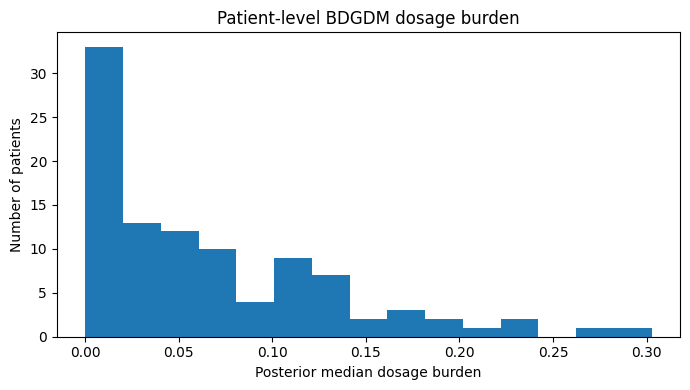

In [89]:
# Dosage burden distribution

import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))

plt.hist(
    wide["dosage_burden_median"]
        .dropna(),
    bins=15,
)

plt.xlabel("Posterior median dosage burden")
plt.ylabel("Number of patients")
plt.title("Patient-level BDGDM dosage burden")
plt.tight_layout()
plt.show()

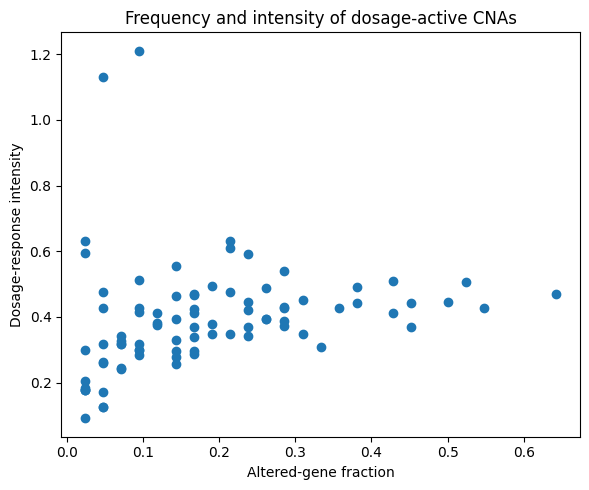

In [91]:
# Altered fraction versus dosage intensity

plt.figure(figsize=(6, 5))

plt.scatter(
    wide["altered_fraction_median"],
    wide["dosage_intensity_median"],
)

plt.xlabel("Altered-gene fraction")
plt.ylabel("Dosage-response intensity")
plt.title("Frequency and intensity of dosage-active CNAs")
plt.tight_layout()
plt.show()

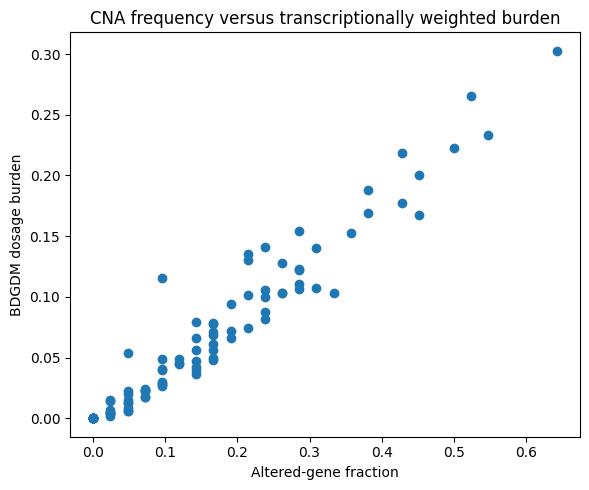

In [93]:
# Ordinary alteration burden versus BDGDM burden
plt.figure(figsize=(6, 5))

plt.scatter(
    wide["altered_fraction_median"],
    wide["dosage_burden_median"],
)

plt.xlabel("Altered-gene fraction")
plt.ylabel("BDGDM dosage burden")
plt.title("CNA frequency versus transcriptionally weighted burden")
plt.tight_layout()
plt.show()

In [95]:
wide = score_result.wide.copy()

print("Rows:", len(wide))
print("Unique patients:", wide["sampleID"].nunique())
print("Duplicated patients:", wide["sampleID"].duplicated().sum())

Rows: 100
Unique patients: 100
Duplicated patients: 0


In [97]:
# Confirm the score identity
draws = score_result.score_draws

expected_burden = (
    draws["altered_fraction"]
    * draws["dosage_intensity"]
)

max_difference = np.nanmax(
    np.abs(
        draws["dosage_burden"]
        - expected_burden
    )
)

print(max_difference)

5.551115123125783e-17


In [99]:
plot_df = (
    score_result.wide
    .drop_duplicates("sampleID")
    .copy()
)

assert len(plot_df) == plot_df["sampleID"].nunique()

In [101]:
correlations = (
    plot_df[
        [
            "altered_fraction_median",
            "dosage_intensity_median",
            "dosage_burden_median",
        ]
    ]
    .corr(method="spearman")
)

correlations

,altered_fraction_median,dosage_intensity_median,dosage_burden_median
altered_fraction_median,1.000000,0.469142,0.972784
dosage_intensity_median,0.469142,1.000000,0.673484
dosage_burden_median,0.972784,0.673484,1.000000


In [103]:
# Compare patient rankings
plot_df = score_result.wide.copy()

plot_df["altered_fraction_rank"] = (
    plot_df["altered_fraction_median"]
    .rank(ascending=False, method="average")
)

plot_df["dosage_burden_rank"] = (
    plot_df["dosage_burden_median"]
    .rank(ascending=False, method="average")
)

plot_df["rank_shift"] = (
    plot_df["altered_fraction_rank"]
    - plot_df["dosage_burden_rank"]
)

plot_df[
    [
        "sampleID",
        "altered_fraction_median",
        "dosage_intensity_median",
        "dosage_burden_median",
        "altered_fraction_rank",
        "dosage_burden_rank",
        "rank_shift",
    ]
].sort_values(
    "rank_shift",
    ascending=False,
)

,sampleID,altered_fraction_median,dosage_intensity_median,dosage_burden_median,altered_fraction_rank,dosage_burden_rank,rank_shift
12,CRC.SW.U0228.T,0.095238,1.210070,0.115245,56.5,20.0,36.5
24,CRC.SW.U0423.T,0.047619,1.129852,0.053802,71.0,45.0,26.0
64,CRC.SW.U3048.T,0.214286,0.629838,0.134965,29.5,15.0,14.5
41,CRC.SW.U0805.T,0.214286,0.610023,0.130719,29.5,16.0,13.5
36,CRC.SW.U0637.T,0.142857,0.556444,0.079492,46.0,33.0,13.0
...,...,...,...,...,...,...,...
96,CRC.SW.UM128.T,0.309524,0.346945,0.107388,13.5,22.0,-8.5
31,CRC.SW.U0465.T,0.142857,0.277167,0.039595,46.0,55.0,-9.0
1,CRC.SW.U0108.T,0.166667,0.286391,0.047732,38.5,49.0,-10.5
22,CRC.SW.U0389.T,0.142857,0.257274,0.036753,46.0,57.0,-11.0


In [105]:
# Examine patients with similar alteration frequency
plot_df["altered_fraction_group"] = pd.qcut(
    plot_df["altered_fraction_median"],
    q=3,
    labels=["low", "intermediate", "high"],
    duplicates="drop",
)

plot_df.groupby(
    "altered_fraction_group",
    observed=True,
).agg(
    n_patients=("sampleID", "size"),
    altered_fraction_median=(
        "altered_fraction_median",
        "median",
    ),
    intensity_min=(
        "dosage_intensity_median",
        "min",
    ),
    intensity_median=(
        "dosage_intensity_median",
        "median",
    ),
    intensity_max=(
        "dosage_intensity_median",
        "max",
    ),
    burden_min=(
        "dosage_burden_median",
        "min",
    ),
    burden_max=(
        "dosage_burden_median",
        "max",
    ),
)

,n_patients,altered_fraction_median,intensity_min,intensity_median,intensity_max,burden_min,burden_max
altered_fraction_group,,,,,,,
low,34,0.023810,0.091705,0.232581,1.129852,0.000000,0.053802
intermediate,32,0.119048,0.241118,0.340764,1.210070,0.017223,0.115245
high,34,0.285714,0.308589,0.429277,0.629838,0.066053,0.302740


In [107]:
# Calculate correlations with proper p-values
from scipy.stats import spearmanr
import pandas as pd

variables = [
    "altered_fraction_median",
    "dosage_intensity_median",
    "dosage_burden_median",
]

rows = []

for i, first in enumerate(variables):
    for second in variables[i + 1:]:
        subset = plot_df[
            [first, second]
        ].dropna()

        rho, p_value = spearmanr(
            subset[first],
            subset[second],
        )

        rows.append(
            {
                "variable_1": first,
                "variable_2": second,
                "n": len(subset),
                "spearman_rho": rho,
                "p_value": p_value,
            }
        )

correlation_results = pd.DataFrame(rows)
correlation_results

,variable_1,variable_2,n,spearman_rho,p_value
0,altered_fraction_median,dosage_intensity_median,84,0.469142,6.751549e-06
1,altered_fraction_median,dosage_burden_median,100,0.972784,4.811169e-64
2,dosage_intensity_median,dosage_burden_median,84,0.673484,2.227987e-12


In [111]:
plot_df = score_result.wide.copy()

print("Patients:", len(plot_df))
print("Missing intensity:", plot_df["dosage_intensity_median"]
        .isna()
        .sum())
print("No altered scored genes:", (plot_df["n_altered_genes"] == 0).sum())

Patients: 100
Missing intensity: 16
No altered scored genes: 16
